# Baseline: TF-IDF + Logistic Regression

Now after the exploration.ipynb which records my exploration process step by step, it is time that I recompile the codes in a more organised and clean manner.

## 1. Explorational Data Analysis(EDA)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Load the datasets
train_df = pd.read_csv('../Data/train.csv')
test_df = pd.read_csv('../Data/test.csv')

# 2. Basic overview
print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

# Inspect the first few rows
# Columns: id, keyword, location, text, target
print(train_df.head())

Training set shape: (7613, 5)
Test set shape: (3263, 4)
   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  


C:\Users\Ziqian Wang\AppData\Local\Temp\ipykernel_13624\3037413681.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='target', palette='viridis')


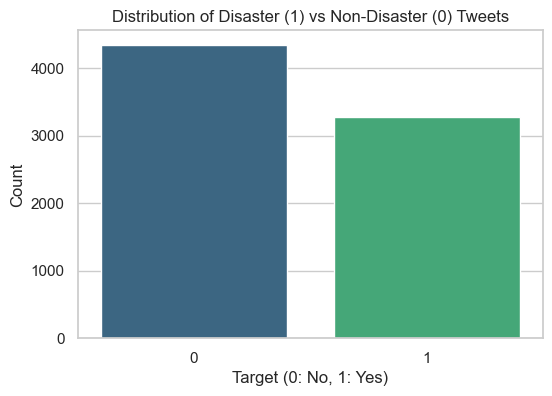

Class Percentages:
target
0    57.034021
1    42.965979
Name: proportion, dtype: float64


In [3]:
# Create a bar plot for the target variable
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='target', palette='viridis')

# Adding labels for clarity
plt.title('Distribution of Disaster (1) vs Non-Disaster (0) Tweets')
plt.xlabel('Target (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

# Calculate exact percentages
print("Class Percentages:")
print(train_df['target'].value_counts(normalize=True) * 100)

In [4]:
# Check for null values in both datasets
print("--- Missing Values in Train ---")
print(train_df.isnull().sum())

print("\n--- Missing Values in Test ---")
print(test_df.isnull().sum())

--- Missing Values in Train ---
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

--- Missing Values in Test ---
id             0
keyword       26
location    1105
text           0
dtype: int64


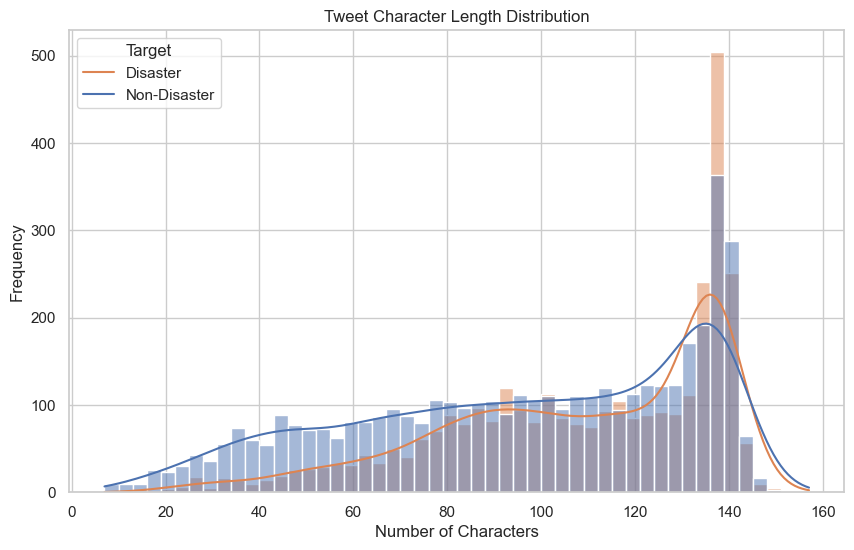

In [5]:
# Calculate length of each tweet (number of characters)
train_df['text_len'] = train_df['text'].apply(len)

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='text_len', hue='target', kde=True, bins=50)

plt.title('Tweet Character Length Distribution')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.legend(title='Target', labels=['Disaster', 'Non-Disaster'])
plt.show()

Now after basic EDA techniques we apply N-Gram Analysis to analyse most frequent word/word pairs.

In [6]:
import nltk
from nltk.corpus import stopwords

# Download the specific resources needed for my code
nltk.download('stopwords')
nltk.download('punkt') # Tokenizer library

print("Setup complete!")

Setup complete!


[nltk_data] Downloading package stopwords to C:\Users\Ziqian
[nltk_data]     Wang\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Ziqian
[nltk_data]     Wang\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


[nltk_data] Downloading package stopwords to C:\Users\Ziqian
[nltk_data]     Wang\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
C:\Users\Ziqian Wang\AppData\Local\Temp\ipykernel_28828\3704333180.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[val[1] for val in top_unigrams_disaster],
C:\Users\Ziqian Wang\AppData\Local\Temp\ipykernel_28828\3704333180.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[val[1] for val in top_bigrams_disaster],


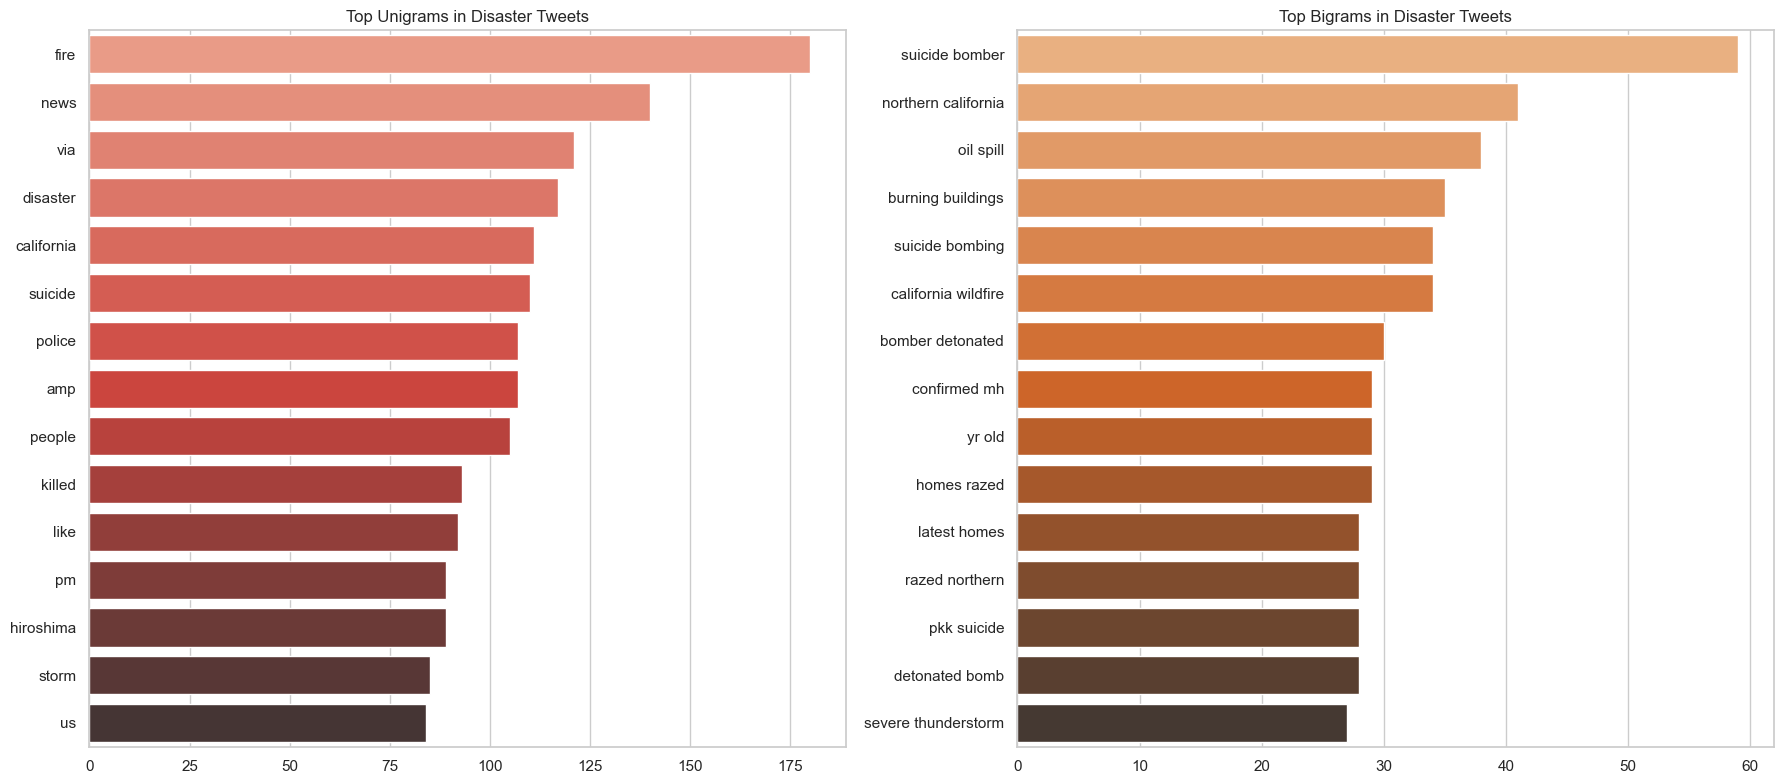

In [7]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
import re

# Download stopwords if you haven't
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def get_top_n_words(corpus, n=20, ngram_range=(1, 1)):
    """
    Extract the most frequent n-grams from the corpus.
    """
    # Simple cleaning for EDA purposes
    words = []
    for text in corpus:
        text = text.lower()
        text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove punctuation and numbers
        tokens = [word for word in text.split() if word not in stop_words]
        
        # Generate n-grams
        if ngram_range == (1, 1):
            words.extend(tokens)
        else:
            # Create bigrams
            bi = list(nltk.bigrams(tokens))
            words.extend([" ".join(b) for b in bi])
            
    return Counter(words).most_common(n)

# 1. Analyze Unigrams for Disaster Tweets (target == 1)
top_unigrams_disaster = get_top_n_words(train_df[train_df['target'] == 1]['text'], n=15)
# 2. Analyze Bigrams for Disaster Tweets
top_bigrams_disaster = get_top_n_words(train_df[train_df['target'] == 1]['text'], n=15, ngram_range=(2, 2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot Unigrams
sns.barplot(x=[val[1] for val in top_unigrams_disaster], 
            y=[val[0] for val in top_unigrams_disaster], ax=axes[0], palette='Reds_d')
axes[0].set_title('Top Unigrams in Disaster Tweets')

# Plot Bigrams
sns.barplot(x=[val[1] for val in top_bigrams_disaster], 
            y=[val[0] for val in top_bigrams_disaster], ax=axes[1], palette='Oranges_d')
axes[1].set_title('Top Bigrams in Disaster Tweets')

plt.tight_layout()
plt.show()

In [8]:
import re
import string

def clean_text(text):
    """
    Standard NLP cleaning pipeline for Tweets.
    """
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove URLs (Very common in tweets)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # 3. Remove HTML tags/entities (Fixes the "amp" issue)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'&amp;', '&', text)
    
    # 4. Remove User Mentions (@user) and Hashtag symbols (#)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    
    # 5. Remove Punctuation
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    
    # 6. Remove extra whitespace
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply the cleaning function to both train and test sets
train_df['text_cleaned'] = train_df['text'].apply(clean_text)
test_df['text_cleaned'] = test_df['text'].apply(clean_text)

# Let's see the difference
print("Original:", train_df['text'].iloc[10])
print("Cleaned :", train_df['text_cleaned'].iloc[10])

Original: Three people died from the heat wave so far
Cleaned : three people died from the heat wave so far


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

# 1. Vectorization
# ngram_range=(1, 2) means we look at single words AND pairs of words
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_train = tfidf.fit_transform(train_df['text_cleaned'])
y_train = train_df['target']

# 2. Model Initialization
# Logistic Regression is fast and interpretable
model_lr = LogisticRegression(max_iter=1000)

# 3. Evaluation using Cross-Validation
# We use 5 folds to ensure the score is stable
cv_scores = cross_val_score(model_lr, X_train, y_train, cv=5, scoring='f1')

print(f"Mean F1 Score: {cv_scores.mean():.4f}")
print(f"Score Variance: {cv_scores.std():.4f}")

# 4. Final Fit
model_lr.fit(X_train, y_train)

Mean F1 Score: 0.6219
Score Variance: 0.0575


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [10]:
import os

# 1. Prepare the test features
# Important: Use the SAME tfidf instance to transform test data
X_test = tfidf.transform(test_df['text_cleaned'])

# 2. Make predictions
test_predictions = model_lr.predict(X_test)

# 3. Create the submission DataFrame
# The format must match sample_submission.csv (id and target)
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'target': test_predictions
})

# 4. Save to the submissions folder
# We use ../ because the notebook is likely inside the src/ folder
output_path = '../submissions/baseline_logistic_regression.csv'

# Ensure the directory exists (just in case)
os.makedirs(os.path.dirname(output_path), exist_ok=True)

submission_df.to_csv(output_path, index=False)

print(f"Successfully generated submission file at: {output_path}")

Successfully generated submission file at: ../submissions/baseline_logistic_regression.csv


In [11]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# 1. Define the pre-trained model checkpoint
model_ckpt = "distilbert-base-uncased"

# 2. Load the tokenizer
# This will split text into sub-words (WordPiece) that BERT understands
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# 3. Load the model with a sequence classification head
# We specify num_labels=2 for our binary classification task
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=2).to(device)

print(f"Using device: {device}")

c:\Users\Ziqian Wang\Desktop\William\Kaggle\nlp-getting-started\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cpu


In [12]:
%pip install transformers torch datasets

Note: you may need to restart the kernel to use updated packages.


In [13]:
# Install/Upgrade accelerate and the torch-compatible version of transformers
%pip install accelerate -U
%pip install transformers[torch] -U

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [14]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# 1. Define the pre-trained model checkpoint
model_ckpt = "distilbert-base-uncased"

# 2. Load the tokenizer
# This will split text into sub-words (WordPiece) that BERT understands
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# 3. Load the model with a sequence classification head
# We specify num_labels=2 for our binary classification task
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=2).to(device)

print(f"Using device: {device}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cpu


In [ ]:
from transformers import Trainer, DataCollatorWithPadding
import inspect
from transformers import TrainingArguments

# ---------- 1) TrainingArguments ----------
ta_params = set(inspect.signature(TrainingArguments.__init__).parameters.keys())

args_kwargs = dict(
    output_dir="./results_distilbert",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    seed=42,
)

if "evaluation_strategy" in ta_params:
    args_kwargs["evaluation_strategy"] = "epoch"
elif "eval_strategy" in ta_params:
    args_kwargs["eval_strategy"] = "epoch"

training_args = TrainingArguments(**args_kwargs)

# ---------- 2) Data collator ----------
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ---------- 3) Trainer ----------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# ---------- 4) Train + Eval ----------
trainer.train()
eval_result = trainer.evaluate()
print("Eval:", eval_result)


C:\Users\Ziqian Wang\AppData\Local\Temp\ipykernel_28828\550261811.py:35: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
c:\Users\Ziqian Wang\Desktop\William\Kaggle\nlp-getting-started\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,F1
1,0.455300,0.380033,0.802013
2,0.348500,0.381442,0.818328


c:\Users\Ziqian Wang\Desktop\William\Kaggle\nlp-getting-started\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Ziqian Wang\Desktop\William\Kaggle\nlp-getting-started\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Eval: {'eval_loss': 0.38144242763519287, 'eval_f1': 0.8183279742765274, 'eval_runtime': 5.8101, 'eval_samples_per_second': 262.128, 'eval_steps_per_second': 8.261, 'epoch': 2.0}


In [24]:
import os

os.chdir(r"C:\Users\Ziqian Wang\Desktop\William\Kaggle\nlp-getting-started")
print("✅ CWD fixed to:", os.getcwd())


✅ CWD fixed to: C:\Users\Ziqian Wang\Desktop\William\Kaggle\nlp-getting-started


In [28]:
import os, glob
from pathlib import Path
import pandas as pd
import torch
import numpy as np

# ------------------ 1) 自动把 cwd 切到项目根目录（含 Data 的目录） ------------------
cwd = Path(os.getcwd())
root = None

for p in [cwd] + list(cwd.parents):
    if (p / "Data").exists():
        root = p
        break

assert root is not None, f"❌ 找不到项目根目录：从 {cwd} 往上都没看到 Data 文件夹"

os.chdir(root)
print("✅ CWD set to project root:", os.getcwd())

# ------------------ 2) 自动找到 test 文件（xlsx/csv/无后缀都支持） ------------------
candidates = [
    "Data/test.xlsx", "Data/test.xls",
    "Data/test.csv",
    "Data/test",  # 无后缀
]
# 兜底：递归搜索
candidates += glob.glob("**/test.xlsx", recursive=True)
candidates += glob.glob("**/test.csv", recursive=True)

test_path = None
for p in candidates:
    if os.path.exists(p):
        test_path = p
        break

assert test_path is not None, "❌ 还是没找到 test 文件。请确认 Data 文件夹里确实有 test。"

print("✅ Found test file:", test_path)

# ------------------ 3) 读取 test ------------------
if test_path.lower().endswith((".xlsx", ".xls")):
    test_df = pd.read_excel(test_path)
else:
    # 无后缀 / csv
    try:
        test_df = pd.read_csv(test_path)
    except Exception:
        test_df = pd.read_excel(test_path)

print("✅ test_df shape:", test_df.shape)

# ------------------ 4) 文本列处理（和训练保持一致） ------------------
if "text_cleaned" not in test_df.columns:
    if "clean_text" in globals():
        test_df["text_cleaned"] = test_df["text"].astype(str).apply(clean_text)
    else:
        test_df["text_cleaned"] = test_df["text"].astype(str)

# ------------------ 5) 推理预测 ------------------
test_encodings = tokenizer(
    list(test_df["text_cleaned"].astype(str)),
    truncation=True,
    max_length=128,
    padding=True,
    return_tensors="pt",
)

model.eval()
all_preds = []

with torch.no_grad():
    for i in range(0, len(test_df), 32):
        batch = {k: v[i:i+32] for k, v in test_encodings.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())

# ------------------ 6) 保存到 submissions/submission1.csv ------------------
os.makedirs("submissions", exist_ok=True)

submission = pd.DataFrame({"id": test_df["id"], "target": all_preds})
out_path = Path("submissions") / "submission1.csv"
submission.to_csv(out_path, index=False)

print("✅ DONE. Saved:", out_path.resolve())
submission.head()


✅ CWD set to project root: C:\Users\Ziqian Wang\Desktop\William\Kaggle\nlp-getting-started
✅ Found test file: Data/test.csv
✅ test_df shape: (3263, 4)
✅ DONE. Saved: C:\Users\Ziqian Wang\Desktop\William\Kaggle\nlp-getting-started\submissions\submission1.csv


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1
